In [1]:
import pandas as pd

df = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541910, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df = df.dropna(subset=['Customer ID'])
df.shape

(406830, 8)

In [5]:
df['Quantity'].describe()

count    406830.000000
mean         12.061276
std         248.693065
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [6]:
df[df['Quantity'] < 0]['Invoice'].astype(str).str[0].value_counts()

Invoice
C    8905
Name: count, dtype: int64

In [7]:
df = df[df['Quantity'] > 0]
df.shape

(397925, 8)

In [8]:
df['Price'].describe()

count    397925.000000
mean          3.116212
std          22.096773
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: Price, dtype: float64

In [9]:
(df['Price'] == 0).sum()

np.int64(40)

In [10]:
df = df[df['Price'] > 0]
df.shape

(397885, 8)

In [11]:
df.to_csv('../data/cleaned/online_retail_cleaned.csv', index=False)

In [12]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [13]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Price': lambda x: (x * df.loc[x.index, 'Quantity']).sum()
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.270609
std,100.014169,7.697998,8989.229895
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [15]:
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

rfm_clean = rfm[rfm['Monetary'] <= upper_limit]
rfm_clean.shape

(3911, 3)

In [16]:
Q1_f = rfm_clean['Frequency'].quantile(0.25)
Q3_f = rfm_clean['Frequency'].quantile(0.75)
IQR_f = Q3_f - Q1_f
upper_limit_f = Q3_f + 1.5 * IQR_f

rfm_clean = rfm_clean[rfm_clean['Frequency'] <= upper_limit_f]
rfm_clean.shape

(3749, 3)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)
rfm_scaled[:5]

array([[-0.27523833,  0.79540148,  1.29053105],
       [-0.82294962, -0.85330483,  1.23829769],
       [ 2.02319297, -0.85330483, -0.63461523],
       [-0.65668012,  2.99367655,  2.22333552],
       [ 0.98645375, -0.85330483, -0.95756982]])

In [18]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

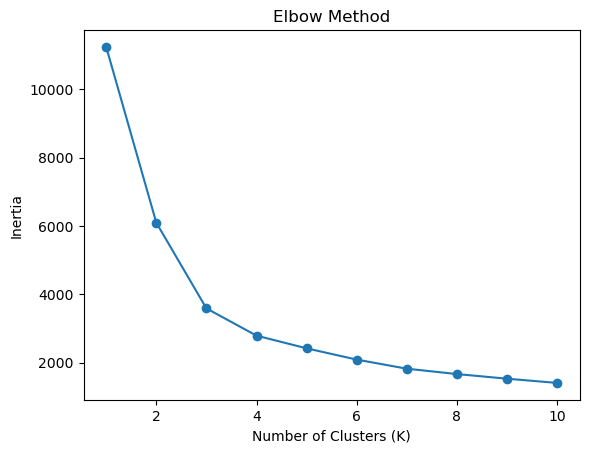

In [19]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,2
12352.0,36,8,2506.04,0
12353.0,204,1,89.00,2


In [21]:
rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,37.960177,5.809735,2396.224847
1,57.441907,1.560107,425.852325
2,259.364416,1.354770,377.116849
3,48.001143,3.836571,1134.244344


In [22]:
rfm_clean.to_csv('../data/cleaned/rfm_clustered.csv')